# Accelerate Large Linear Programs using Distributed PDLP on Multi GPU

NVIDIA cuOpt solves very large Linear Programs (LP) very efficiently on GPU with its implementation of the first-order optimization method known as PDLP (primal-dual hybrid gradient method for LP). This technique can now be run on multi-GPU to further speed up the solution process and allow solving existing LPs faster or solving very large LPs that do not fit in a single GPU memory.

<b>Prerequisite</b>: to run cuOpt PDLP solver on multi-GPU, the node where this notebook is running must have >1 gpus available.

Let's start by verifying your Python version and download the cuOpt package so we are ready to run PDLP on multi-GPU

In [1]:
import sys
current_version = sys.version_info[:2]
if (3, 11) <= current_version <= (3, 14):
    print(f"✅ Success! Your Python version ({sys.version.split()[0]}) is supported.")
else:
    print(f"❌ Version error! Expected >= 3.11 and <= 3.14. Found: {sys.version.split()[0]}")

✅ Success! Your Python version (3.12.15) is supported.


In [2]:
!{sys.executable} -m ensurepip --upgrade
%pip install \
  --extra-index-url=https://pypi.nvidia.com \
  nvidia-cuda-runtime-cu12==12.9.79 \
  cuopt-server-cu12==26.8.0 cuopt-sh-client==26.8.0 matplotlib

Looking in links: /tmp/tmpylt4rjxq
Processing /tmp/tmpylt4rjxq/pip-25.0.1-py3-none-any.whl
Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 116.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 MB 104.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 340.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.7/591.7 MB 271.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 940.0/940.0 kB 111.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.2/725.2 kB 530.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 715.8/715.8 MB 250.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 506.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 416.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 302.1 MB/s eta 0:00:00
     ━━

Let's get the path to the cuOpt binary

In [4]:
import os
from importlib.metadata import distributions

candidates = (
    package.locate_file(entry).resolve()
    for package in distributions()
    if "cuopt" in package.metadata.get("Name", "").lower()
    for entry in package.files or []
    if entry.name == "cuopt_cli"
)

cli_path = next(
    (
        path for path in candidates
        if path.is_file() and os.access(path, os.X_OK)
    ),
    None,
)

if cli_path is None:
    raise FileNotFoundError("No existing, executable cuopt_cli was found.")

CUOPT_CLI = str(cli_path)
CUOPT_HOME = str(cli_path.parent)
os.environ["CUOPT_CLI"] = CUOPT_CLI
os.environ["CUOPT_HOME"] = CUOPT_HOME

print(f"Using: {CUOPT_CLI}")

Using: /home/ubuntu/.venv/bin/cuopt_cli


Let's download a small LP

In [5]:
!wget https://raw.githubusercontent.com/coin-or-tools/Data-Sample/refs/heads/master/afiro.mps

--2026-10-03 12:37:27--  https://raw.githubusercontent.com/coin-or-tools/Data-Sample/refs/heads/master/afiro.mps
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3327 (3.2K) [text/plain]
Saving to: ‘afiro.mps’

afiro.mps           100%[===================>]   3.25K  --.-KB/s    in 0s      

2026-10-03 12:37:28 (101 MB/s) - ‘afiro.mps’ saved [3327/3327]



Now let's ensure we can solve a basic instance (`afiro`) using the **PDLP** agorithm (by setting `method 1`). It is this algorithm (PDLP) that is now accelerated on multiple GPUs.

In [6]:
!$CUOPT_HOME/cuopt_cli --method=1 afiro.mps

Setting parameter method to 1
Reading file afiro.mps
Read file afiro.mps in 0.02 seconds
cuOpt version: 26.8.0, git hash: 400863c1, host arch: x86_64, device archs: 70-real,75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8468, threads (physical/logical): 64/128, RAM (available/total): 1563.50 / 1574.84 GiB
CUDA 12.9, device: NVIDIA H100 80GB HBM3 (ID 0), VRAM: 79.18 GiB
CUDA device UUID: 3a83b2f2-45d6-bafa-1104-035e9548eb47
Solving a problem with 27 constraints, 32 variables (0 integers), and 83 nonzeros
Problem scaling:
Objective coefficents range:          [3e-01, 1e+01]
Constraint matrix coefficients range: [1e-01, 2e+00]
Constraint rhs / bounds range:        [4e+01, 5e+02]
Variable bounds range:                [0e+00, 0e+00]

Using PSLP presolver
PSLP Presolved problem: 21 constraints, 28 variables, 71 non-zeros
PSLP presolve time: 0.04s
Objective offset 440.000000 scaling_factor 1.000000
   Iter    Primal Obj.      Dual Obj.    Gap        Pr

We now build a simple helper to run the solver, parse the log and return the time result.

In [7]:
import re
import subprocess
import os 
# Each successful solve appends {"instance", "num_gpus", "time_s"}.
solve_times = []


def run_cuopt(mps_path, *extra_args, num_gpus=None):
    cmd = [
        os.environ['CUOPT_HOME']+"/cuopt_cli", mps_path, "--method", "1",
        "--relative-primal-tolerance", "1e-6",
        "--relative-dual-tolerance", "1e-6",
        "--relative-gap-tolerance", "1e-6",
        *extra_args,
    ]

    if num_gpus is not None:
        cmd += ["--num-gpus", str(num_gpus)]

    print(
        f"\nRunning {mps_path} with "
        f"{num_gpus if num_gpus is not None else 1} GPUs\n"
    )

    process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    log_lines = []

    for line in process.stdout:
        print(line, end="", flush=True)
        log_lines.append(line)

    process.wait()
    log = "".join(log_lines)

    match = re.search(r"^Status:.*Time:\s*([0-9.]+)s", log, re.M)

    if match is None:
        raise RuntimeError(
            f"No solver Time in cuopt_cli output (exit code {process.returncode})"
        )

    time_s = float(match.group(1))

    solve_times.append({
        "instance": mps_path.rsplit("/", 1)[-1],
        "num_gpus": num_gpus,
        "time_s": time_s,
    })

    return time_s


In [8]:
t_afiro = run_cuopt("afiro.mps")


Running afiro.mps with 1 GPUs

Setting parameter method to 1
Setting parameter relative_dual_tolerance to 1.000000e-06
Setting parameter relative_gap_tolerance to 1.000000e-06
Setting parameter relative_primal_tolerance to 1.000000e-06
Reading file afiro.mps
Read file afiro.mps in 0.02 seconds
cuOpt version: 26.8.0, git hash: 400863c1, host arch: x86_64, device archs: 70-real,75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8468, threads (physical/logical): 64/128, RAM (available/total): 1563.47 / 1574.84 GiB
CUDA 12.9, device: NVIDIA H100 80GB HBM3 (ID 0), VRAM: 79.18 GiB
CUDA device UUID: 3a83b2f2-45d6-bafa-1104-035e9548eb47
Solving a problem with 27 constraints, 32 variables (0 integers), and 83 nonzeros
Problem scaling:
Objective coefficents range:          [3e-01, 1e+01]
Constraint matrix coefficients range: [1e-01, 2e+00]
Constraint rhs / bounds range:        [4e+01, 5e+02]
Variable bounds range:                [0e+00, 0e+00]

Using PSLP pr

In [9]:
print(f"Extracted afiro solve time: {t_afiro}s")

Extracted afiro solve time: 0.1s


## Solving with Multi-GPU PDLP

Let's try again to solve `afiro_original`, but this time with 4 gpus, using the parameter `--num-gpus 4`

In [10]:
t_afiro_4_GPU = run_cuopt("afiro.mps", num_gpus=4)

print(f"\n\nExtracted afiro solve time: {t_afiro_4_GPU}")


Running afiro.mps with 4 GPUs

Setting parameter method to 1
Setting parameter num_gpus to 4
Setting parameter relative_dual_tolerance to 1.000000e-06
Setting parameter relative_gap_tolerance to 1.000000e-06
Setting parameter relative_primal_tolerance to 1.000000e-06
Reading file afiro.mps
Read file afiro.mps in 0.00 seconds
cuOpt version: 26.8.0, git hash: 400863c1, host arch: x86_64, device archs: 70-real,75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8468, threads (physical/logical): 64/128, RAM (available/total): 1563.23 / 1574.84 GiB
CUDA 12.9, device: NVIDIA H100 80GB HBM3 (ID 0), VRAM: 79.18 GiB
CUDA device UUID: 3a83b2f2-45d6-bafa-1104-035e9548eb47
CUDA 12.9, device: NVIDIA H100 80GB HBM3 (ID 1), VRAM: 79.18 GiB
CUDA device UUID: 31c94713-cc96-bcde-e7b4-313ed5752455
CUDA 12.9, device: NVIDIA H100 80GB HBM3 (ID 2), VRAM: 79.18 GiB
CUDA device UUID: c5d55aae-d452-9330-a766-5b5985491d7e
CUDA 12.9, device: NVIDIA H100 80GB HBM3 (ID 3), VRAM

In [11]:
print(f"1 GPU : {t_afiro}s")
print(f"4 GPU : {t_afiro_4_GPU}s")

1 GPU : 0.1s
4 GPU : 1.895s


We don't see much speedup between 1 GPU solve and 4 GPU solve on `afiro`. This is due to the small size of this instance.

Now we download zib03, a large-scale LP problem 

In [12]:
!wget -P datasets/linear_programming/  https://miplib2010.zib.de/contrib/miplib2003-contrib/IPWS2008/zib03.mps.gz
!gunzip datasets/linear_programming/zib03.mps.gz

--2026-10-03 12:38:16--  https://miplib2010.zib.de/contrib/miplib2003-contrib/IPWS2008/zib03.mps.gz
Resolving miplib2010.zib.de (miplib2010.zib.de)... 130.73.131.233
Connecting to miplib2010.zib.de (miplib2010.zib.de)|130.73.131.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 649776384 (620M) [application/x-gzip]
Saving to: ‘datasets/linear_programming/zib03.mps.gz’

zib03.mps.gz        100%[===================>] 619.67M  36.9MB/s    in 18s     

2026-10-03 12:38:34 (34.9 MB/s) - ‘datasets/linear_programming/zib03.mps.gz’ saved [649776384/649776384]



And this larger instance can now be solved on 1, 2, 4 and 8 GPUs with the parameter `--num_gpus`

In [13]:
t_zib03_1_gpu = run_cuopt(
    "datasets/linear_programming/zib03.mps",
    num_gpus=1,
)
t_zib03_1_gpu


Running datasets/linear_programming/zib03.mps with 1 GPUs

Setting parameter method to 1
Setting parameter num_gpus to 1
Setting parameter relative_dual_tolerance to 1.000000e-06
Setting parameter relative_gap_tolerance to 1.000000e-06
Setting parameter relative_primal_tolerance to 1.000000e-06
Reading file zib03.mps
Read file zib03.mps in 119.54 seconds
cuOpt version: 26.8.0, git hash: 400863c1, host arch: x86_64, device archs: 70-real,75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8468, threads (physical/logical): 64/128, RAM (available/total): 1554.92 / 1574.84 GiB
CUDA 12.9, device: NVIDIA H100 80GB HBM3 (ID 0), VRAM: 79.18 GiB
CUDA device UUID: 3a83b2f2-45d6-bafa-1104-035e9548eb47
Solving a problem with 19731970 constraints, 29128799 variables (0 integers), and 104422573 nonzeros
Problem scaling:
Objective coefficents range:          [1e+00, 2e+00]
Constraint matrix coefficients range: [1e+00, 1e+00]
Constraint rhs / bounds range:        [

353.518

In [14]:
t_zib03_2gpu = run_cuopt(
    "datasets/linear_programming/zib03.mps",
    num_gpus=2,
)
t_zib03_4gpu = run_cuopt(
    "datasets/linear_programming/zib03.mps",
    num_gpus=4,
)
t_zib03_8gpu = run_cuopt(
    "datasets/linear_programming/zib03.mps",
    num_gpus=8,
)


Running datasets/linear_programming/zib03.mps with 2 GPUs

Setting parameter method to 1
Setting parameter num_gpus to 2
Setting parameter relative_dual_tolerance to 1.000000e-06
Setting parameter relative_gap_tolerance to 1.000000e-06
Setting parameter relative_primal_tolerance to 1.000000e-06
Reading file zib03.mps
Read file zib03.mps in 117.53 seconds
cuOpt version: 26.8.0, git hash: 400863c1, host arch: x86_64, device archs: 70-real,75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8468, threads (physical/logical): 64/128, RAM (available/total): 1550.08 / 1574.84 GiB
CUDA 12.9, device: NVIDIA H100 80GB HBM3 (ID 0), VRAM: 79.18 GiB
CUDA device UUID: 3a83b2f2-45d6-bafa-1104-035e9548eb47
CUDA 12.9, device: NVIDIA H100 80GB HBM3 (ID 1), VRAM: 79.18 GiB
CUDA device UUID: 31c94713-cc96-bcde-e7b4-313ed5752455
CUDA 12.9, device: NVIDIA H100 80GB HBM3 (ID 2), VRAM: 79.18 GiB
CUDA device UUID: c5d55aae-d452-9330-a766-5b5985491d7e
CUDA 12.9, device: NVID

And now let's take a look at the solve times and compare the PDLP solver performance over multiple GPUs.

In [16]:
print(f"1 GPU : {t_zib03_1_gpu}s")
print(f"2 GPUs: {t_zib03_2gpu}s")
print(f"4 GPUs: {t_zib03_4gpu}s")
print(f"8 GPUs: {t_zib03_8gpu}s")

1 GPU : 353.518s
2 GPUs: 204.316s
4 GPUs: 121.071s
8 GPUs: 87.904s


In [17]:
import matplotlib.pyplot as plt

def plot_gpu_times(instance):
    instance_name = f"{instance}.mps"
    # Convert None to 1 GPU
    for r in solve_times:
        if r["num_gpus"] is None:
            r["num_gpus"] = 1

    # Filter and sort
    rows = sorted(
        [r for r in solve_times if r["instance"] == instance_name],
        key=lambda r: r["num_gpus"]
    )

    if not rows:
        print(f"No data found for {instance_name}")
        return

    gpus = [r["num_gpus"] for r in rows]
    times = [r["time_s"] for r in rows]

    plt.figure(figsize=(8, 5))
    plt.title(f"PDLP Solve Time for {instance}")
    bars = plt.bar(
        range(len(gpus)),
        times,
        color="#76B900",
        width=0.5
    )

    plt.xlabel("Number of GPUs")
    plt.ylabel("Solve time (s)")
    plt.xticks(range(len(gpus)), gpus)

    for bar, time in zip(bars, times):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            time,
            f"{time:.2f}s",
            ha="center",
            va="bottom",
        )

    plt.show()

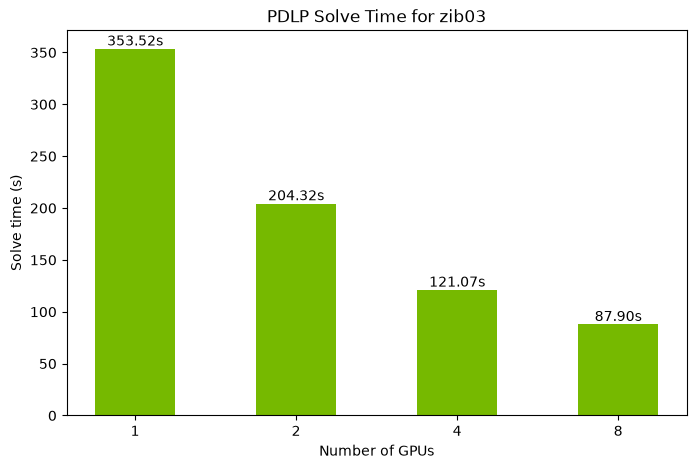

In [18]:
plot_gpu_times("zib03")

We encourage you to test multi-GPU PDLP on your own LPs and share with us your experience!

In [ ]:
path = "path/to/your/lp/file.mps"
run_cuopt(path, num_gpus=1)
run_cuopt(path, num_gpus=8)

plot_gpu_times(path.rsplit("/", 1)[-1])